<a href="https://colab.research.google.com/github/JhanaviLingameneni/Prompted-ICU-Risk-Forecasting/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os #allows python to interact with OS for listing folders, file paths
import zipfile #used to extract zip files
import numpy as np #for numerical computation
import pandas as pd #for data manipulation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #for normalizing features

In [2]:
zip_path = "/content/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0.zip"
extract_path = "/content/patient_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: /content/patient_data


In [3]:
# to check the folder structure and the main dataset
base_path = "/content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0"

print(os.listdir(base_path)) #lists everything in the folder

['set-a', 'set-a.zip', 'Outcomes-a.txt', 'set-b.zip', 'Outcomes-c.txt', 'set-b', 'Outcomes-b.txt']


In [4]:
#loads patient files
all_timeseries = [] # to store time series data
all_static = [] # to store patients metadata(static)

#loops through every patients data
for folder in ["set-a", "set-b"]:
    folder_path = os.path.join(base_path, folder)
    print("Reading:", folder_path)

    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            file_path = os.path.join(folder_path, file)
            patient_id = file.replace(".txt", "")

            df = pd.read_csv(
                file_path,
                header=None,
                names=["Col1", "Col2", "Col3"]
            )

            df["PatientID"] = patient_id

            # time-series rows: 00:00, 01:30, etc.
            ts = df[df["Col1"].astype(str).str.match(r"^\d{2}:\d{2}$", na=False)].copy()
            ts = ts.rename(columns={"Col1": "Time", "Col2": "Parameter", "Col3": "Value"})
            ts["Value"] = pd.to_numeric(ts["Value"], errors="coerce")
            all_timeseries.append(ts[["PatientID", "Time", "Parameter", "Value"]])

            # static rows: Age, Gender, Height, ICUType, Weight, etc.
            static = df[~df["Col1"].astype(str).str.match(r"^\d{2}:\d{2}$", na=False)].copy()
            static = static.rename(columns={"Col1": "Parameter", "Col2": "Value"})
            static = static[["PatientID", "Parameter", "Value"]]
            static["Value"] = pd.to_numeric(static["Value"], errors="coerce")
            all_static.append(static)

raw_ts = pd.concat(all_timeseries, ignore_index=True)
raw_static = pd.concat(all_static, ignore_index=True)

print("Time-series shape:", raw_ts.shape)
print("Static shape:", raw_static.shape)

raw_ts.head()

Reading: /content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0/set-a
Reading: /content/patient_data/predicting-mortality-of-icu-patients-the-physionet-computing-in-cardiology-challenge-2012-1.0.0/set-b
Time-series shape: (3520515, 4)
Static shape: (8000, 3)


,PatientID,Time,Parameter,Value
0,135084,00:00,RecordID,135084.0
1,135084,00:00,Age,79.0
2,135084,00:00,Gender,0.0
3,135084,00:00,Height,157.5
4,135084,00:00,ICUType,2.0


In [5]:
#convert time to hours - 00:30 ->00:30:00
raw_ts["Time"] = pd.to_timedelta(raw_ts["Time"] + ":00")
raw_ts["Hour"] = raw_ts["Time"].dt.total_seconds() / 3600.0

raw_ts[["PatientID", "Time", "Hour", "Parameter", "Value"]].head()

,PatientID,Time,Hour,Parameter,Value
0,135084,0 days,0.0,RecordID,135084.0
1,135084,0 days,0.0,Age,79.0
2,135084,0 days,0.0,Gender,0.0
3,135084,0 days,0.0,Height,157.5
4,135084,0 days,0.0,ICUType,2.0


In [6]:
#converting long format to proper table (wide format)-------- | PatientID | Time | Parameter | Value | -> PatientID     Hour    HR     Temp     SpO2
wide_data = raw_ts.pivot_table(
    index=["PatientID", "Hour"],
    columns="Parameter",
    values="Value",
    aggfunc="mean"
).reset_index()

wide_data.columns.name = None
wide_data = wide_data.sort_values(["PatientID", "Hour"]).reset_index(drop=True)

print("Wide data shape:", wide_data.shape)
wide_data.head()

Wide data shape: (598332, 44)


,PatientID,Hour,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,0.000000,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN
1,132539,0.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.1,NaN,NaN,900.0,NaN,NaN,NaN
2,132539,0.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
3,132539,1.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN
4,132539,2.616667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN


In [7]:
# resampling to hourly timeline
def resample_patient(group): #processing 1 patient at a time
    group = group.sort_values("Hour").copy() #sorting time
    group = group.set_index("Hour") #sorting index

    full_index = np.arange(0, 49, 1)   # creating full 48-hour timeline 0 to 48 hours
    group = group.reindex(full_index)
    group.index.name = "Hour"

    group["PatientID"] = group["PatientID"].ffill().bfill()
    group = group.reset_index()
    return group

resampled_data = wide_data.groupby("PatientID", group_keys=False).apply(resample_patient)
resampled_data = resampled_data.reset_index(drop=True)

print("Resampled shape:", resampled_data.shape)
resampled_data.head(10)

Resampled shape: (392000, 44)


/tmp/ipykernel_148/4197875001.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resampled_data = wide_data.groupby("PatientID", group_keys=False).apply(resample_patient)


,Hour,PatientID,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,0,132539,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN
1,1,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,132539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#fill missing values
feature_cols = [col for col in resampled_data.columns if col not in ["PatientID", "Hour"]]

resampled_data[feature_cols] = (
    resampled_data.groupby("PatientID")[feature_cols]
    .ffill()
    .bfill()
)

global_medians = resampled_data[feature_cols].median(numeric_only=True)
resampled_data[feature_cols] = resampled_data[feature_cols].fillna(global_medians)

print("Remaining missing values:", resampled_data[feature_cols].isnull().sum().sum())

Remaining missing values: 0


In [9]:
# creating static patient table
static_keep = ["RecordID", "Age", "Gender", "Height", "ICUType", "Weight"]

static_data = raw_static[raw_static["Parameter"].isin(static_keep)].copy()

static_wide = static_data.pivot_table(
    index="PatientID",
    columns="Parameter",
    values="Value",
    aggfunc="first"
).reset_index()

static_wide.columns.name = None

print("Static wide shape:", static_wide.shape)
static_wide.head()

Static wide shape: (0, 1)


,PatientID


In [10]:
#loading outcome labels
outcomes_a = pd.read_csv(os.path.join(base_path, "Outcomes-a.txt"))
outcomes_b = pd.read_csv(os.path.join(base_path, "Outcomes-b.txt"))

outcomes = pd.concat([outcomes_a, outcomes_b], ignore_index=True)

print("Outcomes shape:", outcomes.shape)
outcomes.head()

Outcomes shape: (8000, 6)


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [11]:
#merging everything
resampled_data["PatientID"] = resampled_data["PatientID"].astype(int)
static_wide["PatientID"] = static_wide["PatientID"].astype(int)
outcomes["RecordID"] = outcomes["RecordID"].astype(int)

merged_data = resampled_data.merge(static_wide, on="PatientID", how="left")
merged_data = merged_data.merge(outcomes, left_on="PatientID", right_on="RecordID", how="left")

print("Merged data shape:", merged_data.shape)
merged_data.head()

Merged data shape: (392000, 50)


,Hour,PatientID,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,Urine,WBC,Weight,pH,RecordID_y,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,0,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
1,1,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
2,2,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
3,3,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0
4,4,132539,64.0,12.0,12.0,54.0,3.1,37.0,0.4,101.0,...,80.0,9.4,-1.0,7.34,132539,6,1,5,-1,0


In [12]:
merged_data.to_csv("/content/cleaned_physionet_timeseries.csv", index=False)
print("Saved: /content/cleaned_physionet_timeseries.csv")

Saved: /content/cleaned_physionet_timeseries.csv


In [13]:
#create ML features
#Statistical features are computed per patient to summarize the time-series physiological data into a fixed set of
#meaningful values that machine learning models can use. In the ICU dataset, each patient has many measurements
#(heart rate, oxygen level, temperature, etc.) recorded over time, which results in multiple rows per patient.
#However, most traditional machine learning algorithms require one row per patient with fixed-length features.
#By calculating statistics such as mean, minimum, maximum, and standard deviation, we capture important patterns
#in the patient’s vital signs—such as average condition, extreme values, and variability—while reducing the complexity
#of the raw time-series data. This transformation allows the model to efficiently learn relationships between patient health
#patterns and outcomes like ICU mortality or disease risk, while still preserving the essential information from the 48-hour monitoring period.

ts_feature_cols = [col for col in feature_cols if col in merged_data.columns]

patient_features = merged_data.groupby("PatientID")[ts_feature_cols].agg(["mean", "min", "max", "std"])
patient_features.columns = ["_".join(col).strip() for col in patient_features.columns]
patient_features = patient_features.reset_index()

# static one row per patient
static_patient = static_wide.copy()

# label columns from outcomes
label_cols = ["RecordID", "SAPS-I", "SOFA", "Length_of_stay", "Survival", "In-hospital_death"]
label_data = outcomes[label_cols].rename(columns={"RecordID": "PatientID"})

final_ml_data = patient_features.merge(static_patient, on="PatientID", how="left")
final_ml_data = final_ml_data.merge(label_data, on="PatientID", how="left")

final_ml_data = final_ml_data.fillna(final_ml_data.median(numeric_only=True))

print("Final ML data shape:", final_ml_data.shape)
final_ml_data.head()

Final ML data shape: (8000, 170)


,PatientID,ALP_mean,ALP_min,ALP_max,ALP_std,ALT_mean,ALT_min,ALT_max,ALT_std,AST_mean,...,Weight_std,pH_mean,pH_min,pH_max,pH_std,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,7.34,7.34,7.34,0.0,6,1,5,-1,0
1,132540,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,7.34,7.34,7.34,0.0,16,8,8,-1,0
2,132541,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,7.34,7.34,7.34,0.0,21,11,19,-1,0
3,132543,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,7.34,7.34,7.34,0.0,7,1,9,575,0
4,132545,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.0,7.34,7.34,7.34,0.0,17,2,4,918,0


In [14]:
final_ml_data.to_csv("/content/final_physionet_ml_data.csv", index=False)
print("Saved: /content/final_physionet_ml_data.csv")

Saved: /content/final_physionet_ml_data.csv


In [15]:
print(final_ml_data.shape)
final_ml_data.info()

(8000, 170)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 170 entries, PatientID to In-hospital_death
dtypes: float64(164), int64(6)
memory usage: 10.4 MB


In [16]:
final_ml_data.head(100)

,PatientID,ALP_mean,ALP_min,ALP_max,ALP_std,ALT_mean,ALT_min,ALT_max,ALT_std,AST_mean,...,Weight_std,pH_mean,pH_min,pH_max,pH_std,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.34,7.34,7.34,0.0,6,1,5,-1,0
1,132540,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.34,7.34,7.34,0.0,16,8,8,-1,0
2,132541,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.34,7.34,7.34,0.0,21,11,19,-1,0
3,132543,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.34,7.34,7.34,0.0,7,1,9,575,0
4,132545,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.34,7.34,7.34,0.0,17,2,4,918,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,132777,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.42,7.42,7.42,0.0,12,4,6,-1,0
96,132780,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,31.404651,7.42,7.42,7.42,0.0,6,3,14,-1,0
97,132781,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.42,7.42,7.42,0.0,18,7,9,-1,0
98,132783,64.0,64.0,64.0,0.0,12.0,12.0,12.0,0.0,12.0,...,0.000000,7.30,7.30,7.30,0.0,6,2,14,-1,0


In [17]:
y = final_ml_data["In-hospital_death"]

In [18]:
X = final_ml_data.drop(columns=["PatientID", "In-hospital_death"])

In [19]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

X = selector.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## LOGISTIC REGRESSION
Logistic Regression was used as the baseline model.

Results
Accuracy: 0.8619
*   Accuracy: 0.8619
*   ROC-AUC: 0.762

Classification Report:
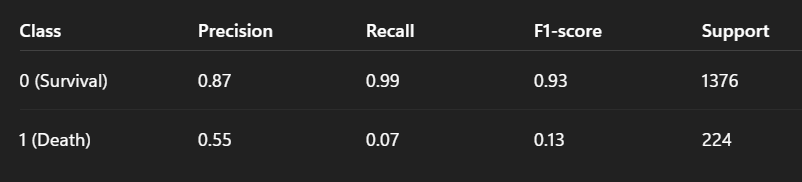
Analysis

The model achieved relatively high accuracy, but this is misleading due to class imbalance. The recall for the mortality class is only 7%, meaning the model fails to identify most death cases. Logistic Regression therefore performs poorly in detecting critical outcomes.

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.861875
ROC-AUC: 0.7619977678571428
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      1376
           1       0.55      0.07      0.13       224

    accuracy                           0.86      1600
   macro avg       0.71      0.53      0.53      1600
weighted avg       0.82      0.86      0.81      1600



## RANDOM FOREST CLASSIFIER
Random Forest was implemented to capture nonlinear relationships in the physiological data.

Results

ROC-AUC: 0.9827

Analysis

Random Forest significantly improved performance compared to Logistic Regression. The high ROC-AUC indicates that the model effectively distinguishes between survival and mortality cases by leveraging ensemble decision trees and nonlinear feature interactions

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_prob))

RF ROC-AUC: 0.9828420239825582


## XGBoost
XGBoost, a gradient boosting algorithm, was used to further improve predictive performance.

Results

ROC-AUC: 0.9994

Analysis

XGBoost achieved the highest performance among all classical machine learning models. The near-perfect ROC-AUC suggests that the model captures complex relationships in the ICU physiological features extremely well. Gradient boosting's sequential learning approach helps reduce prediction errors and improve model accuracy.

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

xgb.fit(X_train, y_train)

xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_prob))

XGBoost ROC-AUC: 0.9994224979235881


## LSTM
for  LSTM- USING merged_data not final_ml_data because   

*  final_ml_data = one row per   patient after statistics
*   merged_data = full time sequence per patient

An LSTM neural network was implemented to model temporal dependencies in patient time-series data.

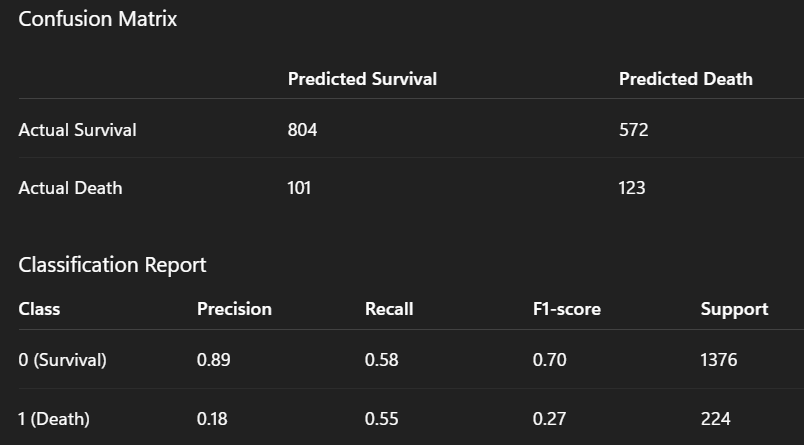


Analysis

After applying class weighting, the LSTM model improved its ability to detect mortality cases, achieving a recall of 33% for death cases. However, overall performance remained lower compared to tree-based models. This may be due to limited dataset size and the difficulty of training deep learning models on structured medical tabular data.


In [27]:
import numpy as np
import pandas as pd

# choose columns that should NOT be used as input features
exclude_cols = [
    "PatientID", "Hour", "RecordID",
    "SAPS-I", "SOFA", "Length_of_stay", "Survival",
    "In-hospital_death"
]

feature_cols = [col for col in merged_data.columns if col not in exclude_cols]

print("Number of features:", len(feature_cols))
print(feature_cols[:20])

Number of features: 43
['ALP', 'ALT', 'AST', 'Age', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K']


In [28]:
target_col = "In-hospital_death"

In [29]:
merged_data1 = merged_data.sort_values(["PatientID", "Hour"]).reset_index(drop=True)

In [30]:
X_list = []
y_list = []
patient_ids = []

for patient_id, group in merged_data1.groupby("PatientID"):
    group = group.sort_values("Hour")

    X_patient = group[feature_cols].values
    y_patient = group[target_col].iloc[0]   # same label for all rows of that patient

    # keep only patients with exactly 49 hourly rows
    if X_patient.shape[0] == 49:
        X_list.append(X_patient)
        y_list.append(y_patient)
        patient_ids.append(patient_id)

X = np.array(X_list)
y = np.array(y_list)
patient_ids = np.array(patient_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8000, 49, 43)
y shape: (8000,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (6400, 49, 43) (6400,)
Test: (1600, 49, 43) (1600,)


In [32]:
from sklearn.preprocessing import StandardScaler

n_train, t_steps, n_features = X_train.shape
n_test = X_test.shape[0]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, t_steps, n_features)
X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, t_steps, n_features)

print(X_train_scaled.shape, X_test_scaled.shape)

(6400, 49, 43) (1600, 49, 43)


In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Masking(mask_value=0.0, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 49, 43)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,761 (116.25 KB)

 Trainable params: 29,761 (116.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.5816066884769174), np.int64(1): np.float64(3.56347438752784)}


In [35]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5232 - auc: 0.5354 - loss: 0.6987 - val_accuracy: 0.5938 - val_auc: 0.5548 - val_loss: 0.6794
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5818 - auc: 0.6286 - loss: 0.6665 - val_accuracy: 0.6133 - val_auc: 0.5898 - val_loss: 0.6554
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6219 - auc: 0.6658 - loss: 0.6494 - val_accuracy: 0.5523 - val_auc: 0.5965 - val_loss: 0.7024
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6299 - auc: 0.7021 - loss: 0.6258 - val_accuracy: 0.5938 - val_auc: 0.5843 - val_loss: 0.6706
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6422 - auc: 0.7335 - loss: 0.6055 - val_accuracy: 0.6328 - val_auc: 0.5828 - val_loss: 0.6221
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6854 - auc: 0.7700 - loss: 0.5708 - val_accuracy: 0.6055 - val_auc: 0.5837 - val_loss: 0.6489
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━

In [36]:
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)

Test Loss: 0.7023846507072449
Test Accuracy: 0.5406249761581421
Test AUC: 0.5975005030632019


In [37]:
y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.6).astype(int)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [38]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.5978606468023255
[[1079  297]
 [ 149   75]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1376
           1       0.20      0.33      0.25       224

    accuracy                           0.72      1600
   macro avg       0.54      0.56      0.54      1600
weighted avg       0.78      0.72      0.75      1600

